# ResNet18

This notebook trains a **ResNet18** model on Mel Spectrogram representations of the audio tracks.

### Overview
- **Input**: Image-like data (`mel_arrays` directory) containing `.npy` files of Mel Spectrograms for each audio segment.
- **Model**: `ResNet18` architecture (from `torchvision.models`), pre-trained on ImageNet and fine-tuned for audio genre classification. The input single-channel spectrograms are duplicated across 3 channels to match the expected input shape.
- **Training**: Uses PyTorch `DataLoader` with augmentations like TimeMasking and FrequencyMasking to prevent overfitting.

### Usage on Kaggle
If running on Kaggle, ensure the dataset is mounted and update the `DATA_DIR` path to point to `../input/song-genre-classification/mel_arrays/`.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. You might have the CPU-only version of PyTorch installed.")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [12]:
class MelSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        npy_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Load Mel Spectrogram
        mel_spec = np.load(npy_path)
        if mel_spec.min() >= 0:
            mel_spec = np.log(mel_spec + 1e-9)
        mel_spec = np.nan_to_num(mel_spec, nan=0.0, posinf=0.0, neginf=-100.0)
        
        # Normalize to 0-1 range
        delta = mel_spec.max() - mel_spec.min()
        if delta > 1e-6:
            mel_spec = (mel_spec - mel_spec.min()) / delta
        else:
            # Handle silence/flat files
            mel_spec = np.zeros_like(mel_spec)
        
        # Convert to tensor and add channel dimension (1, H, W)
        mel_spec = torch.from_numpy(mel_spec).float().unsqueeze(0)
        
        # ResNet expects 3 channels, so we repeat the single channel 3 times
        mel_spec = mel_spec.repeat(3, 1, 1)
        
        if self.transform:
            mel_spec = self.transform(mel_spec)
            
        return mel_spec, label

In [ ]:
# Configuration
DATA_DIR = r".../mel_arrays" # Relative path to mel_arrays from models folder
BATCH_SIZE = 16
NUM_EPOCHS = 35
LEARNING_RATE = 1e-3 # Back to 1e-3 for frozen backbone

# Gather files and track info
file_paths = []
labels = []
track_ids = []
classes = os.listdir(DATA_DIR)

for label in classes:
    class_dir = os.path.join(DATA_DIR, label)
    if not os.path.isdir(class_dir):
        continue
    for f in os.listdir(class_dir):
        if f.endswith('.npy'):
            file_paths.append(os.path.join(class_dir, f))
            labels.append(label)
            
            # Extract track_id (e.g., "rock_100" from "rock_100_seg1.npy")
            track_id = f.split('_seg')[0]
            track_ids.append(track_id)

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)

print(f"Found {len(file_paths)} files across {num_classes} classes: {le.classes_}")

# Group by track_id for splitting
track_to_label = {}
for tid, lbl in zip(track_ids, labels_encoded):
    track_to_label[tid] = lbl

unique_tracks = list(track_to_label.keys())
unique_track_labels = list(track_to_label.values())

# Split tracks: 75% Train, 15% Val, 10% Test
train_tracks, temp_tracks, y_train_tracks, y_temp_tracks = train_test_split(
    unique_tracks, unique_track_labels, 
    test_size=0.25, 
    random_state=42, 
    stratify=unique_track_labels
)

val_tracks, test_tracks, y_val_tracks, y_test_tracks = train_test_split(
    temp_tracks, y_temp_tracks, 
    test_size=0.4, 
    random_state=42, 
    stratify=y_temp_tracks
)

# --- VERIFICATION STEP ---
train_ids_set = set(train_tracks)
val_ids_set = set(val_tracks)
test_ids_set = set(test_tracks)

assert len(train_ids_set.intersection(val_ids_set)) == 0, "CRITICAL: Train and Val sets overlap!"
assert len(train_ids_set.intersection(test_ids_set)) == 0, "CRITICAL: Train and Test sets overlap!"
assert len(val_ids_set.intersection(test_ids_set)) == 0, "CRITICAL: Val and Test sets overlap!"
print("SUCCESS: Data split verified. No song leakage between sets.")
# -------------------------

print(f"Tracks split: Train={len(train_tracks)}, Val={len(val_tracks)}, Test={len(test_tracks)}")

# Map back to file paths
train_files, val_files, test_files = [], [], []
train_labels, val_labels, test_labels = [], [], []

for fp, lbl, tid in zip(file_paths, labels_encoded, track_ids):
    if tid in train_ids_set:
        train_files.append(fp)
        train_labels.append(lbl)
    elif tid in val_ids_set:
        val_files.append(fp)
        val_labels.append(lbl)
    elif tid in test_ids_set:
        test_files.append(fp)
        test_labels.append(lbl)

print(f"Segments split: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

# Enhanced Augmentation & Normalization
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([torchaudio.transforms.TimeMasking(time_mask_param=30)], p=0.5),
    transforms.RandomApply([torchaudio.transforms.FrequencyMasking(freq_mask_param=20)], p=0.5),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

train_dataset = MelSpectrogramDataset(train_files, train_labels, transform=train_transforms)
val_dataset = MelSpectrogramDataset(val_files, val_labels, transform=val_transforms)
test_dataset = MelSpectrogramDataset(test_files, test_labels, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Found 16281 files across 9 classes: ['country' 'edm' 'hiphop' 'jazz' 'kpop' 'lofi' 'pop' 'r&b' 'rock']
SUCCESS: Data split verified. No song leakage between sets.
Tracks split: Train=1323, Val=265, Test=177
Segments split: Train=12226, Val=2430, Test=1625


Visualizing Training Data...
Batch Mean: -0.1098, Std: 0.8550
Batch Min: -2.1179, Max: 2.6020


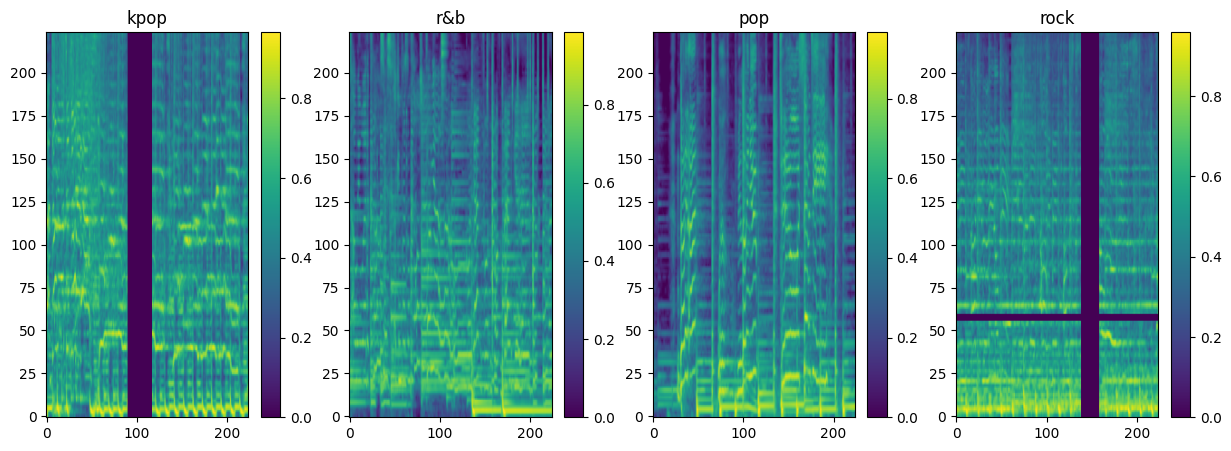

Visualizing Validation Data...
Batch Mean: -0.4461, Std: 1.2017
Batch Min: -2.1179, Max: 2.5746


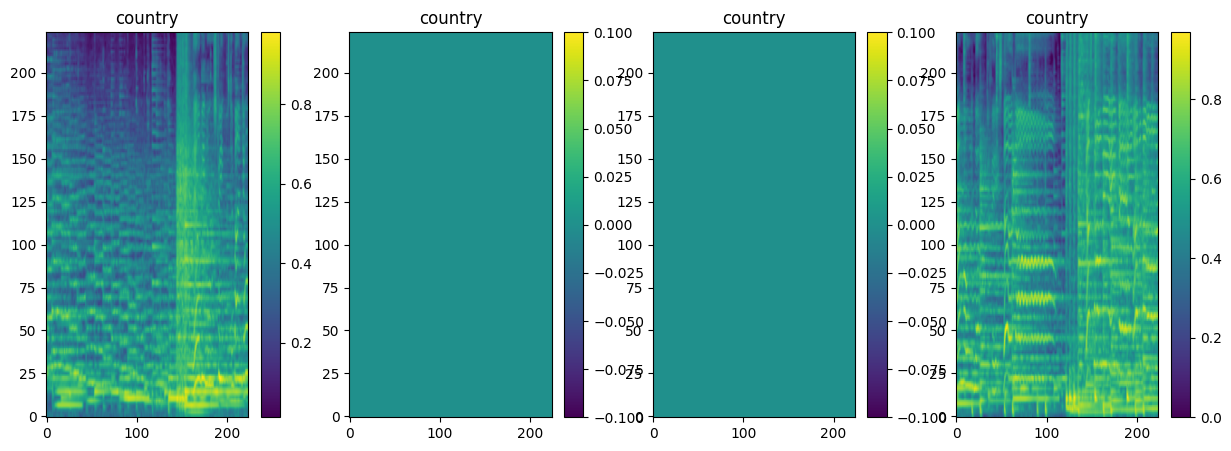

In [15]:
def show_batch(dataloader):
    inputs, classes = next(iter(dataloader))
    
    # Calculate stats
    print(f"Batch Mean: {inputs.mean():.4f}, Std: {inputs.std():.4f}")
    print(f"Batch Min: {inputs.min():.4f}, Max: {inputs.max():.4f}")
    
    # Denormalize for visualization (approximate)
    inputs_vis = inputs.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    inputs_vis = inputs_vis * std + mean
    
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    for i in range(4):
        ax = axes[i]
        # Show first channel
        img = inputs_vis[i][0].numpy()
        im = ax.imshow(img, origin='lower', aspect='auto', cmap='viridis')
        ax.set_title(le.inverse_transform([classes[i]])[0])
        plt.colorbar(im, ax=ax)
    plt.show()

print("Visualizing Training Data...")
show_batch(train_loader)
print("Visualizing Validation Data...")
show_batch(val_loader)

In [16]:
model = models.resnet18(pretrained=True)

# Initially freeze all layers
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes) 
)

# Unfreeze top ResNet blocks for fine-tuning
for name, param in model.named_parameters():
    if "layer4" in name or "layer3" in name:
        param.requires_grad = True

model = model.to(device)

# Verify freezing
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Percentage Trainable: {100 * trainable_params / total_params:.2f}%")

criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 3e-4  # lower LR for fine-tuning
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=0.05)

# Cosine Annealing Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda')

f:\Python\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
f:\Python\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Total Parameters: 11,443,785
Trainable Parameters: 10,760,713
Percentage Trainable: 94.03%


In [17]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, patience=5):
    train_acc_history = []
    val_acc_history = []
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloader, desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    # Mixed Precision Training
                    # Updated to use torch.amp.autocast to avoid FutureWarning
                    with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
            else:
                val_acc_history.append(epoch_acc.item())
                
                # Deep copy the model if it's the best
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        print(f"Best Val Acc: {best_acc:.4f}")
        
        # Early Stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history

import copy # Need copy for deepcopy
trained_model, train_hist, val_hist = train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS, patience=5)

Epoch 1/35
----------


train:   0%|          | 0/765 [00:00<?, ?it/s]

train: 100%|██████████| 765/765 [00:42<00:00, 17.87it/s]


train Loss: 1.3660 Acc: 0.5196


val: 100%|██████████| 152/152 [00:05<00:00, 29.58it/s]



...

val Loss: 2.0186 Acc: 0.6477
Best Val Acc: 0.6638
Epoch 14/35
----------


train: 100%|██████████| 765/765 [00:54<00:00, 13.98it/s]


train Loss: 0.1442 Acc: 0.9513


val: 100%|██████████| 152/152 [00:07<00:00, 19.96it/s]

val Loss: 1.9801 Acc: 0.6366
Best Val Acc: 0.6638
Early stopping triggered after 14 epochs!
Best val Acc: 0.663786


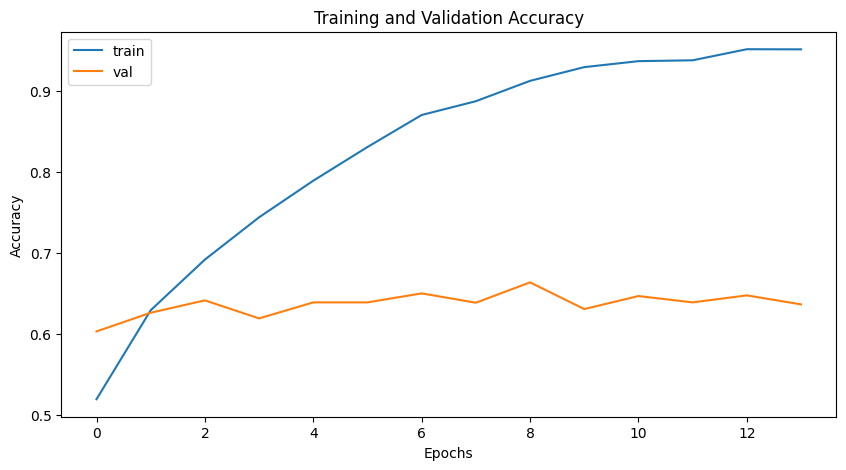

In [18]:
plt.figure(figsize=(10, 5))
plt.title("Training and Validation Accuracy")
plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
torch.save(trained_model.state_dict(), 'resnet18.pth')
print("Model saved successfully.")

Model saved successfully.


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10332\1470884012.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('resnet18_genre.pth'))


Evaluating on Test Set...


Testing: 100%|██████████| 102/102 [00:05<00:00, 18.82it/s]




Test Accuracy: 0.6677

Classification Report:
              precision    recall  f1-score   support

     country       0.65      0.69      0.67       192
         edm       0.57      0.65      0.61       215
      hiphop       0.75      0.62      0.68       163
        jazz       0.76      0.94      0.84        99
        kpop       0.72      0.61      0.66       198
        lofi       0.95      0.92      0.94       174
         pop       0.50      0.40      0.45       196
         r&b       0.62      0.76      0.69       182
        rock       0.59      0.59      0.59       206

    accuracy                           0.67      1625
   macro avg       0.68      0.69      0.68      1625
weighted avg       0.67      0.67      0.66      1625



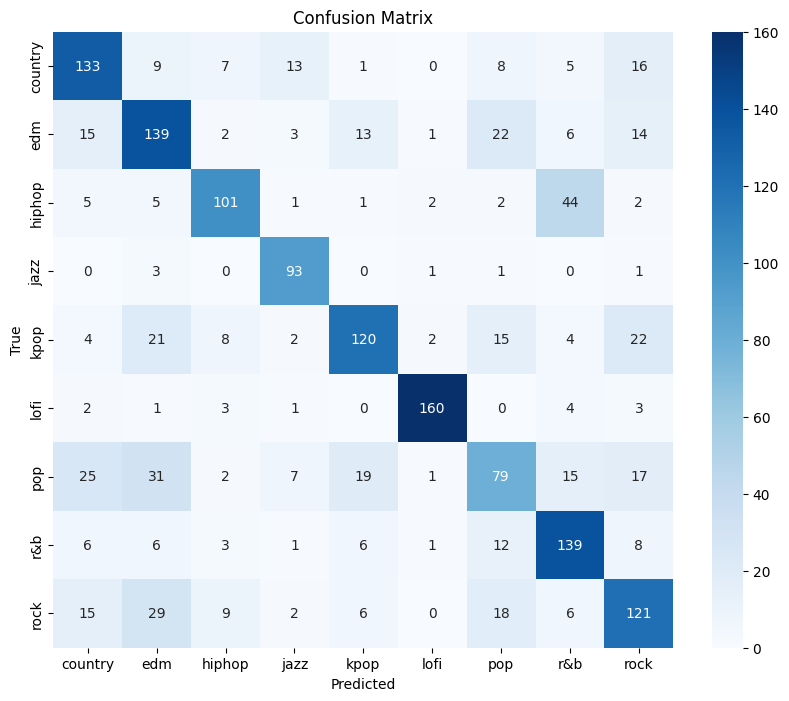

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load the best model weights
model.load_state_dict(torch.load('resnet18.pth'))
model.eval()

all_preds = []
all_labels = []

print("Evaluating on Test Set...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Accuracy
correct = np.sum(np.array(all_preds) == np.array(all_labels))
accuracy = correct / len(all_labels)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()